# LeetCode #94: Binary Tree Inorder Traversal

https://leetcode.com/problems/binary-tree-inorder-traversal/

## Comparison of Approaches

| Approach | Time | Space | Notes |
|----------|------|-------|-------|
| Recursive DFS | O(n) | O(n) | Simple; uses call stack |
| **Iterative Stack ★** | **O(n)** | **O(n)** | Explicit stack; go left until null, process, go right |
| Morris Traversal | O(n) | O(1) | Modifies tree temporarily; threaded links |

---

## Understanding the Methods

### Brute Force (Recursive)
```
void Inorder(TreeNode node) { Inorder(node.left); result.Add(node.val); Inorder(node.right); }
```
Clean but uses O(h) call stack space (h = tree height).

### Optimal: Iterative Stack ★
Simulate recursion with an explicit stack:
1. Push current node, go left until null.
2. Pop: process node (add val), then explore right subtree.

Loop condition: `curr != null OR stack non-empty` covers all states.

**Constraints:**
* Number of nodes: [0, 100]
* Node values: [-100, 100]

## Solutions

### C#

In [ ]:
public class Solution {
    public IList<int> InorderTraversal(TreeNode root) {
        var result = new List<int>();
        var stack = new Stack<TreeNode>();
        var curr = root;

        while (curr != null || stack.Count > 0) {
            // Go as far left as possible
            while (curr != null) {
                stack.Push(curr);
                curr = curr.left;
            }
            // Backtrack: process node, then explore right
            curr = stack.Pop();
            result.Add(curr.val);
            curr = curr.right;
        }

        return result;
    }
}

### Python

In [ ]:
class Solution:
    def inorderTraversal(self, root) -> list[int]:
        result = []
        stack = []
        curr = root

        while curr or stack:
            while curr:
                stack.append(curr)
                curr = curr.left
            curr = stack.pop()
            result.append(curr.val)
            curr = curr.right

        return result

### Go

In [ ]:
func inorderTraversal(root *TreeNode) []int {
    result := []int{}
    stack := []*TreeNode{}
    curr := root

    for curr != nil || len(stack) > 0 {
        for curr != nil {
            stack = append(stack, curr)
            curr = curr.Left
        }
        curr = stack[len(stack)-1]
        stack = stack[:len(stack)-1]
        result = append(result, curr.Val)
        curr = curr.Right
    }

    return result
}

### Rust

In [ ]:
impl Solution {
    pub fn inorder_traversal(root: Option<Rc<RefCell<TreeNode>>>) -> Vec<i32> {
        let mut result = Vec::new();
        let mut stack: Vec<Rc<RefCell<TreeNode>>> = Vec::new();
        let mut curr = root;

        loop {
            while let Some(node) = curr {
                let left = node.borrow().left.clone();
                stack.push(node);
                curr = left;
            }
            match stack.pop() {
                None => break,
                Some(node) => {
                    result.push(node.borrow().val);
                    curr = node.borrow().right.clone();
                }
            }
        }

        result
    }
}

## Example Scenarios

### 1. Common Case — Balanced BST
**Input:** `root = [4, 2, 6, 1, 3, 5, 7]`

Inorder of a BST yields sorted values. Push 4,2,1 (go left). Pop 1, pop 2 (go right to 3), pop 3, pop 4 (go right to 6), push 6,5, pop 5, pop 6, push 7, pop 7.

*Why tricky:* Classic balanced BST confirms inorder = sorted. Tests both left and right subtree exploration with the explicit stack.

$n = 7$ nodes. Stack max depth $= O(\log n) = 3$. Each node pushed and popped exactly once.

**Output:** `[1, 2, 3, 4, 5, 6, 7]`

---

### 2. Slightly Complex — Right-Skewed with Left Child
**Input:** `root = [1, null, 2, 3]` (1's right = 2, 2's left = 3)

Push 1 (no left). Pop 1 → output 1, go right to 2. Push 2, go left to 3. Push 3 (no left). Pop 3 → output 3. Pop 2 → output 2.

*Why tricky:* Non-trivial structure where a left child appears deep in the right subtree. Tests that the go-left logic re-engages after a right move.

$n = 3$. Stack max depth $= 2$. Each node visited exactly once.

**Output:** `[1, 3, 2]`

---

### 3. Edge Case: Time Factor — Left-Skewed Chain (100 Nodes)
**Input:** `root = 100 \to 99 \to \ldots \to 1` (all left children)

The inner while-loop pushes all 100 nodes before any popping. Then each pop outputs the node with no right child. Total: 100 pushes + 100 pops.

*Why tricky:* Worst-case time for the initial left-drill — stack fills to maximum depth $n = 100$ before any output.

$n = 100$ (max constraint). Stack depth $= 100 = O(n)$. Output $= [1, 2, \ldots, 100]$.

**Output:** `[1, 2, 3, ..., 100]`

---

### 4. Edge Case: Space Factor — Right-Skewed Chain (100 Nodes)
**Input:** `root = 1 \to 2 \to \ldots \to 100` (all right children)

Push 1 (no left), pop 1, go right to 2. Repeat. Stack never holds more than 1 node at a time. Best case for space.

*Why tricky:* Stack max depth $= 1$ (best case $O(1)$) but still $O(n)$ time. Demonstrates that space depends on tree shape, not just $n$.

Stack max size $= 1$. Time still $O(100)$.

**Output:** `[1, 2, 3, ..., 100]`

---

### 5. Almost-Impossible but Plausible — All Identical Boundary Values
**Input:** `root = [-100, -100, -100, -100, -100, -100, -100]` (perfect tree, all val = -100)

Every node has value $-100$ (constraint minimum). Inorder visits all 7 nodes left-to-right by position. Algorithm is value-agnostic — it purely follows structure.

*Why tricky:* All-identical boundary values verify the algorithm does not rely on value comparisons. Node val $= -100$ is at the constraint minimum.

$n = 7$, depth $= 3$. Output $= [-100, -100, -100, -100, -100, -100, -100]$.

**Output:** `[-100, -100, -100, -100, -100, -100, -100]`

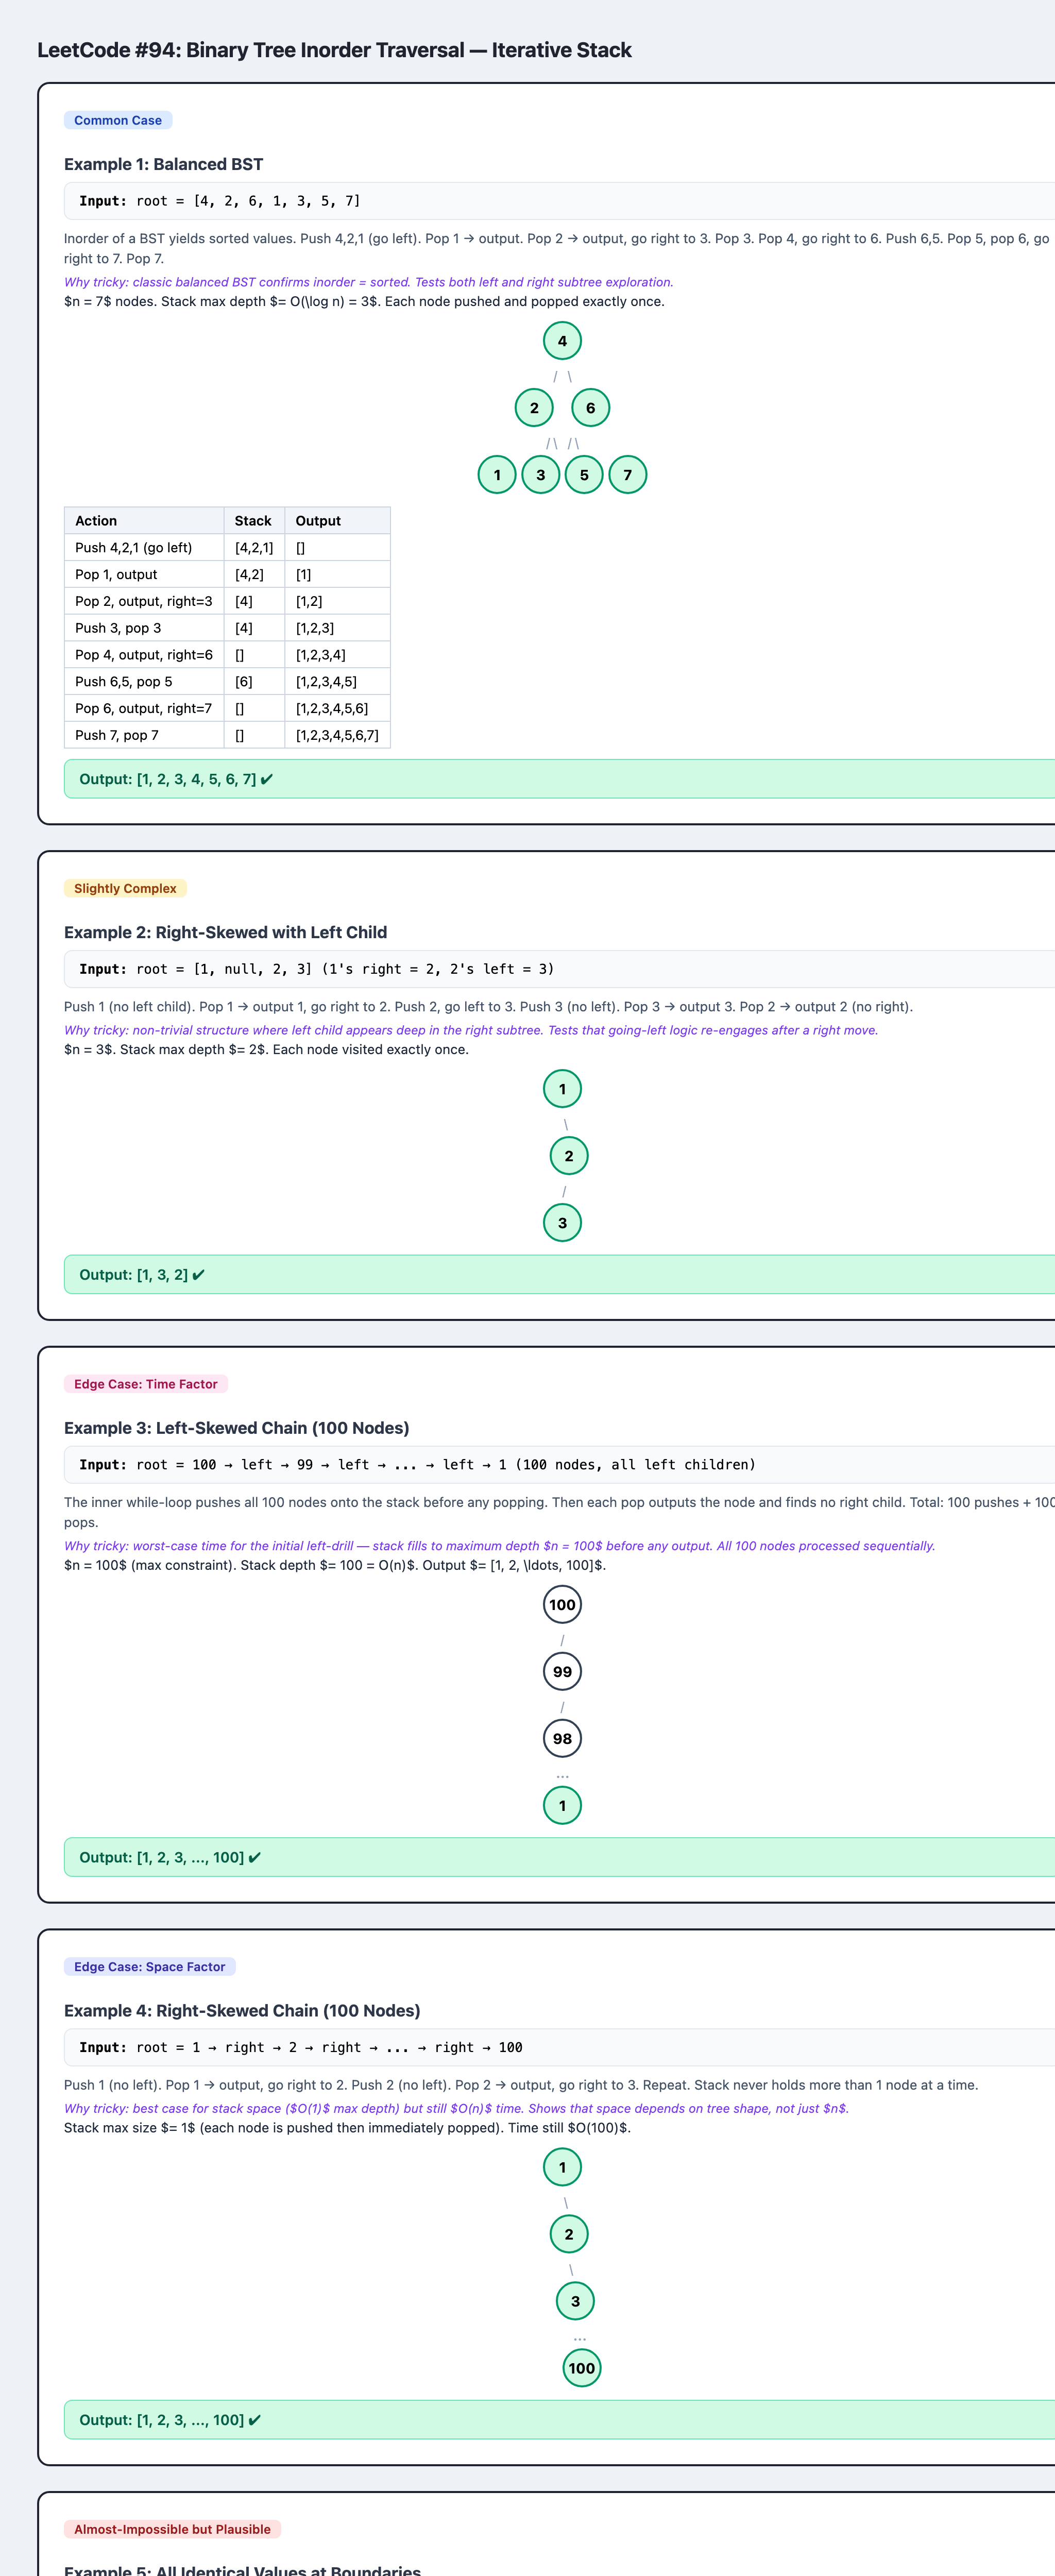